# Initialization

In [ ]:
# imports

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
from pyvis.network import Network
import math
from networkx.algorithms.community import asyn_lpa_communities, modularity
from typing import Literal

In [15]:

random.seed(67)
np.random.seed(67)

base = Path("data")

def clean_columns(data):
    cleaned = []
    for col in data:
        col = col.replace("#", "")
        col = col.strip()
        cleaned.append(col)
    data.columns = cleaned

nodes = pd.read_csv(base / "nodes.csv")
edges = pd.read_csv(base / "edges.csv")

clean_columns(nodes)
clean_columns(edges)


print(nodes.head)
print(edges.head)


<bound method NDFrame.head of      index     name
0        0    Aemon
1        1    Grenn
2        2  Samwell
3        3    Aerys
4        4    Jaime
..     ...      ...
102    102   Ramsay
103    103  Chataya
104    104  Shireen
105    105    Doran
106    106   Walton

[107 rows x 2 columns]>
<bound method NDFrame.head of      source  target  weight
0         0       1       5
1         0       2      31
2         2      82       6
3         2      58      34
4         2      76      12
..      ...     ...     ...
347      94       5       6
348      98      97       4
349     101      16       4
350     104      72       5
351     106       4      10

[352 rows x 3 columns]>


# helper methods

In [16]:
# mathematical helpers

def get_und_avg_deg(graph):
    return (2*graph.number_of_edges())/graph.number_of_nodes()

def get_und_density(graph):
    return (get_und_avg_deg(graph)/(graph.number_of_nodes()-1))

# lcc - largest connected component
def get_und_lcc(graph):
    nodes = (max(nx.connected_components(graph), key=len))
    return graph.subgraph(nodes).copy()

# takes number of nodes as an imput and returns max number of possible connections between them, undirected, no self loop
def get_und_max_edges(num_nodes):
    return (num_nodes*(num_nodes-1))/2


# Week 1

explanation

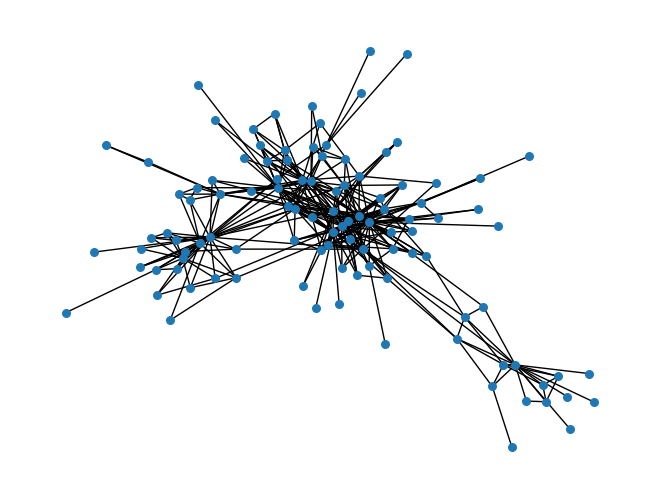

Number of Self Loops: 0


In [17]:
# graphing our data

G = nx.Graph()

# storing names under attribute called name for each node
for i in range(len(nodes)):
    idx = nodes["index"][i]
    name = nodes["name"][i]
    G.add_node(idx, name = name)

weighted_edge_list = list(zip(edges["source"], edges["target"], edges["weight"]))
G.add_weighted_edges_from(weighted_edge_list)

position = nx.spring_layout(G, seed=67)

nx.draw(G, pos=position, node_size=30)

plt.show()

#hopefully 0
print(f"Number of Self Loops: {nx.number_of_selfloops(G)}")

In [18]:
# showing number of nodes and edges
print(f"Total Number of Nodes:   {G.number_of_nodes()}")
print(f"Total Number of Edges:   {G.number_of_edges()}")
print(f"Average Degree of Graph: {round(get_und_avg_deg(G), 2)}")
print(f"Density of Graph:        {round(get_und_density(G), 2)}")

"""
Comment: 

This graph has a pretty low density. Only 6% of possible connections are there.
Each node is roughly connected to 6 or 7 others.
"""

Total Number of Nodes:   107
Total Number of Edges:   352
Average Degree of Graph: 6.58
Density of Graph:        0.06


'\nComment: \n\nThis graph has a pretty low density. Only 6% of possible connections are there.\nEach node is roughly connected to 6 or 7 others.\n'

# Week 2

explanation

In [19]:
# designing functions for node clustering and avg clustering


# for largest clustered componedt pass in get_und_lcc(graph)
def get_und_node_clustering(graph, node):

    neighbors = list(graph.neighbors(node))
    max_edges = get_und_max_edges(len(neighbors))

    if max_edges == 0:
        return 0

    edge_count = 0

    for i in range(len(neighbors)):
        for j in range(i+1, len(neighbors)):
            if graph.has_edge(neighbors[i], neighbors[j]):
                edge_count+=1

    return edge_count/max_edges
                
# returns a dataframe with columns "node" and "clustering_coeff"
def get_clustering_at_every_node(graph):
    clustering_info = {}

    for node in graph.nodes():
        clustering_info[node] = get_und_node_clustering(graph, node)

    return pd.DataFrame({
        "node": clustering_info.keys(), "clustering_coeff": clustering_info.values()
        })

def get_avg_clustering(graph):
    cluster_df = get_clustering_at_every_node(graph)
    return cluster_df["clustering_coeff"].sum()/len(cluster_df)

In [20]:
# running average clustering calculations with largest connected component

lcc = get_und_lcc(G)

print(f"My Function's Average Clusering of lcc:              {round(get_avg_clustering(lcc), 4)}")
print(f"The Built in Function for Average Clustering of lcc: {round(nx.average_clustering(lcc), 4)}")
print(f"The Transitivity of lcc:                             {round(nx.transitivity(lcc), 4)}")

My Function's Average Clusering of lcc:              0.5514
The Built in Function for Average Clustering of lcc: 0.5514
The Transitivity of lcc:                             0.3287


# Week 3

explanation

In [21]:
# helper functions

# computing cumulative distribution this takes in a dataframe with clustering information for each node
# pass in df first then the name of the column with the clustering information
# it first returns vals being a sorted list of clustering coefficients  (x axis)
# it then returns cdf which is the fraction of values that are <= each value in vals (y axis)

def get_cumulative_distribution(clustering_df,column):
    
    vals = clustering_df[column].sort_values().to_numpy()
    cdf = np.arange(1, len(vals) + 1) / len(vals)

    return vals, cdf


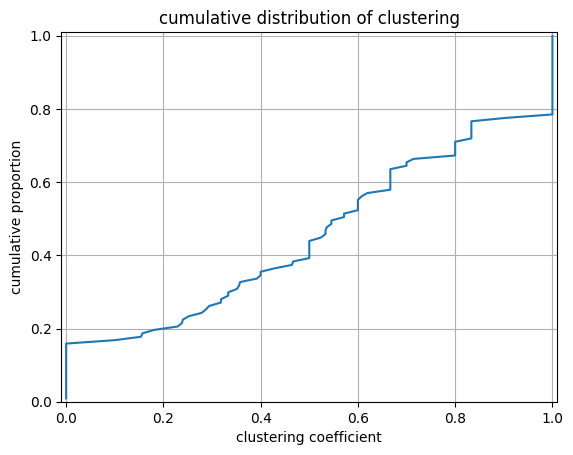

' \nThe intermediate distribution line is pretty smooth.\nThis indicates that the intermediate clusters are not concentrated at low or high values.\nIndicates that the network has a mix of nodes, some in weakly clustered neighborhoods while others in strongly clustered local groups.\nInitial Jump at 0 means that a noticable share of nodes have clustering coefficient equal or close to 0.\nThe large jump near 1 suggests that a large number of nodes have clustering coefficients close to 1, meaning their neighbors are highly connected.\n'

In [22]:
# Task 1 Cumulative Distribuiton of Clustering

# create a df with all clustering
clustering_df = get_clustering_at_every_node(G)

cluster_x, cluster_y = get_cumulative_distribution(clustering_df, "clustering_coeff")

plt.plot(cluster_x, cluster_y)
plt.xlabel("clustering coefficient")
plt.ylabel("cumulative proportion")
plt.title("cumulative distribution of clustering")
plt.xlim(-0.01, 1.01)
plt.ylim(0, 1.01)
plt.grid(True)
plt.show()

''' 
The intermediate distribution line is pretty smooth.
This indicates that the intermediate clusters are not concentrated at low or high values.
Indicates that the network has a mix of nodes, some in weakly clustered neighborhoods while others in strongly clustered local groups.
Initial Jump at 0 means that a noticable share of nodes have clustering coefficient equal or close to 0.
The large jump near 1 suggests that a large number of nodes have clustering coefficients close to 1, meaning their neighbors are highly connected.
'''

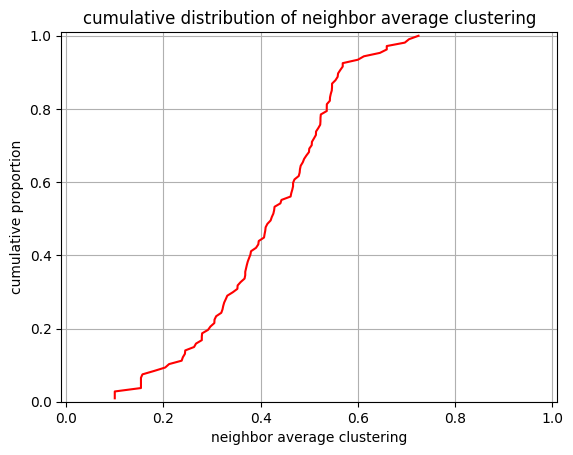

'\nThe average clustering of neighbors is concentrated in the middle range.\nThis makes since considering that we are taking the averages.\nThe curve rises steeply in the range of ~0.3-0.55. - This means many nodes have avg neighbor clustering in this range.\nIt shows that almost no nodes have average neighbors who are weakly or strongly clustered.\nThis shows that the local environments of nodes are pretty well balanced, more cohesive, and less clique-like.\n'

In [23]:
# Task 2 Average clustering of Neighbors

# converting clustering at every node df to dictionary for easier lookup
clustering_df = get_clustering_at_every_node(G)
clustering_dict = dict(zip(clustering_df["node"], clustering_df["clustering_coeff"]))

# building a dictionary containing each node and their average clustering of their neighbors
neighbor_avg_cluster = {}

for node in G.nodes():

    neighbors = list(G.neighbors(node))
    if len(neighbors) == 0:
        neighbor_avg_cluster[node] = 0
        continue

    total_cluster = 0
    count = 0

    for neighbor in neighbors:
        total_cluster += clustering_dict[neighbor]
        count += 1

    neighbor_avg_cluster[node] = total_cluster/count

neighbor_avg_cluster_df = pd.DataFrame({"node": neighbor_avg_cluster.keys(), "clustering_coeff": neighbor_avg_cluster.values()})

neighbor_x, neighbor_y = get_cumulative_distribution(neighbor_avg_cluster_df, "clustering_coeff")

plt.plot(neighbor_x, neighbor_y, color = "red")
plt.xlabel("neighbor average clustering")
plt.ylabel("cumulative proportion")
plt.title("cumulative distribution of neighbor average clustering")
plt.xlim(-0.01, 1.01)
plt.ylim(0, 1.01)
plt.grid(True)
plt.show()

'''
The average clustering of neighbors is concentrated in the middle range.
This makes since considering that we are taking the averages.
The curve rises steeply in the range of ~0.3-0.55. - This means many nodes have avg neighbor clustering in this range.
It shows that almost no nodes have average neighbors who are weakly or strongly clustered.
This shows that the local environments of nodes are pretty well balanced, more cohesive, and less clique-like.
'''


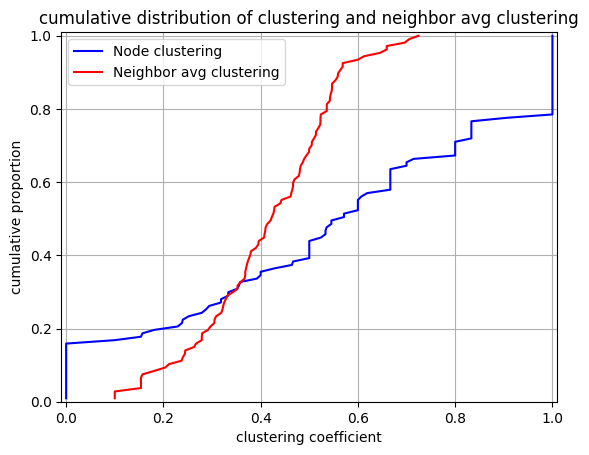

'\nComparing the two distributions, the neighbor avg clustering is much more concentrated in the intermediate range.\nThe curve for node clustering is much more spread out. The red curve is below the blue one at low values suggesting\naverage clustering of neighbors smooths out extreme values for nodes.\n'

In [24]:
# plotting both distirbution of nodes and neighbors on top of each other

plt.plot(cluster_x, cluster_y, color="blue", label="Node clustering")
plt.plot(neighbor_x, neighbor_y, color="red", label="Neighbor avg clustering")

plt.xlabel("clustering coefficient")
plt.ylabel("cumulative proportion")
plt.title("cumulative distribution of clustering and neighbor avg clustering")
plt.xlim(-0.01, 1.01)
plt.ylim(0, 1.01)
plt.grid(True)
plt.legend()
plt.show()

'''
Comparing the two distributions, the neighbor avg clustering is much more concentrated in the intermediate range.
The curve for node clustering is much more spread out. The red curve is below the blue one at low values suggesting
average clustering of neighbors smooths out extreme values for nodes.
'''

# Week 5

In this Game of Thrones (GoT) character coappearance network, betweenness and closeness are a strong pair because they capture two complementary forms of centrality. Betweenness identifies characters who act as bridges between different characters (story world), while closeness identifies characters who are, on average, only a few steps away from others in the network. This is relevant to GoT because the narrative is split across multiple factions and locations, so both brokerage and overall reach matter. From the outputs, the most central by betweenness are Jon, Robert, Tyrion, Daenerys, Robb, and Sansa; by closeness, the top nodes are Tyrion, Sansa, Robert, Robb, Arya, and Jaime. The overlap shows a consistent core of globally important characters. 

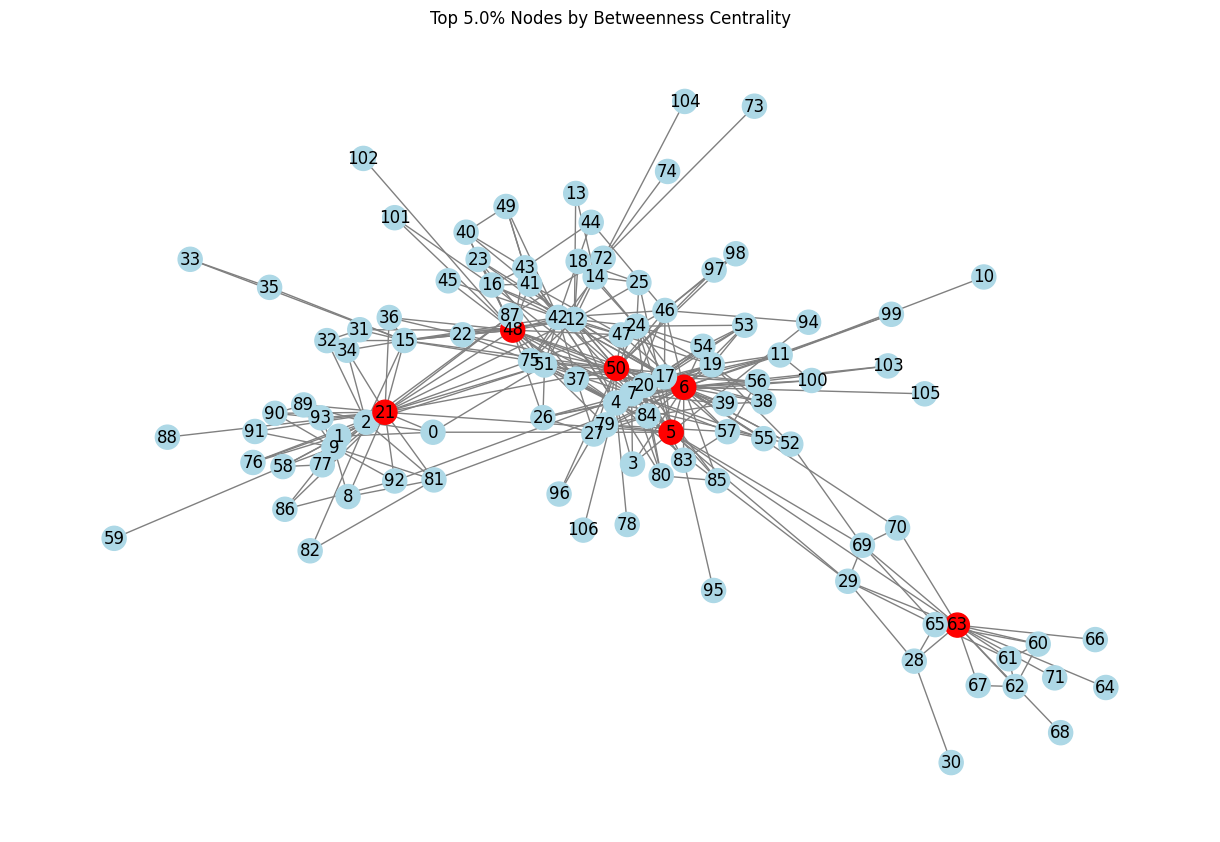

Node: Jon, Number: 21, Betweenness Centrality: 0.22996466368472643
Node: Robert, Number: 5, Betweenness Centrality: 0.2094523840293199
Node: Tyrion, Number: 6, Betweenness Centrality: 0.19791284320277416
Node: Daenerys, Number: 63, Betweenness Centrality: 0.1572034521205509
Node: Robb, Number: 48, Betweenness Centrality: 0.12696447138301634
Node: Sansa, Number: 50, Betweenness Centrality: 0.126720316684981


In [ ]:
def detect_betweenness_centrality(graph, top_percent=5.0):

    G = graph
    nodes = G.nodes()
    
    if len(nodes) < 3:
        raise ValueError("Graph must have at least 3 nodes to compute betweenness centrality.") # Not enough nodes to compute betweenness centrality     
    
    seen_pairs = set()
    betweenness = {node: 0.0 for node in G.nodes()}
    num_nodes = G.number_of_nodes()
    scale = 2.0 / ((num_nodes - 1) * (num_nodes - 2))

    for n in nodes:
        
        connected_component = networkx.node_connected_component(G, n)
        target = connected_component - {n}
        
        for c in target:
            pair = frozenset((n, c))   # undirected pair used because needed a immutable varible for dict key
            if pair in seen_pairs:
                continue
            seen_pairs.add(pair)

            shortest_paths = list(networkx.all_shortest_paths(G, source=n, target=c))
            sigma_st = len(shortest_paths) #total number of shortest paths between n and c

            for path in shortest_paths:
                for v in path[1:-1]:   # exclude endpoints n and c
                    betweenness[v] += (1.0 / sigma_st) * scale
    
    # betweenness: {node: score}
    items = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

    percent = top_percent  # top percent
    k = max(1, math.ceil(len(items) * (percent / 100.0)))

    top_nodes = dict(items[:k]) 
    return top_nodes

def plot_top_betweenness(graph, top_percent=5.0):
    top_nodes = detect_betweenness_centrality(graph, top_percent)
    G = graph.copy()
    
    node_colors = []
    for node in G.nodes():
        if node in top_nodes:
            node_colors.append('red')  # Highlight top nodes in red
        else:
            node_colors.append('lightblue')  # Other nodes in light blue

    pos = nx.spring_layout(G, seed=67)
    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=300, edge_color='gray')
    plt.title(f'Top {top_percent}% Nodes by Betweenness Centrality')
    plt.show()


plot_top_betweenness(G, top_percent=5.0)
# Build once
id_to_name = nodes.set_index(nodes["index"].astype(int))["name"].to_dict()

betweenness = detect_betweenness_centrality(G, top_percent=5.0)

for node_id, score in betweenness.items():
    name = id_to_name.get(int(node_id), "Unknown")
    print(f"Node: {name}, Number: {node_id}, Betweenness Centrality: {score}")




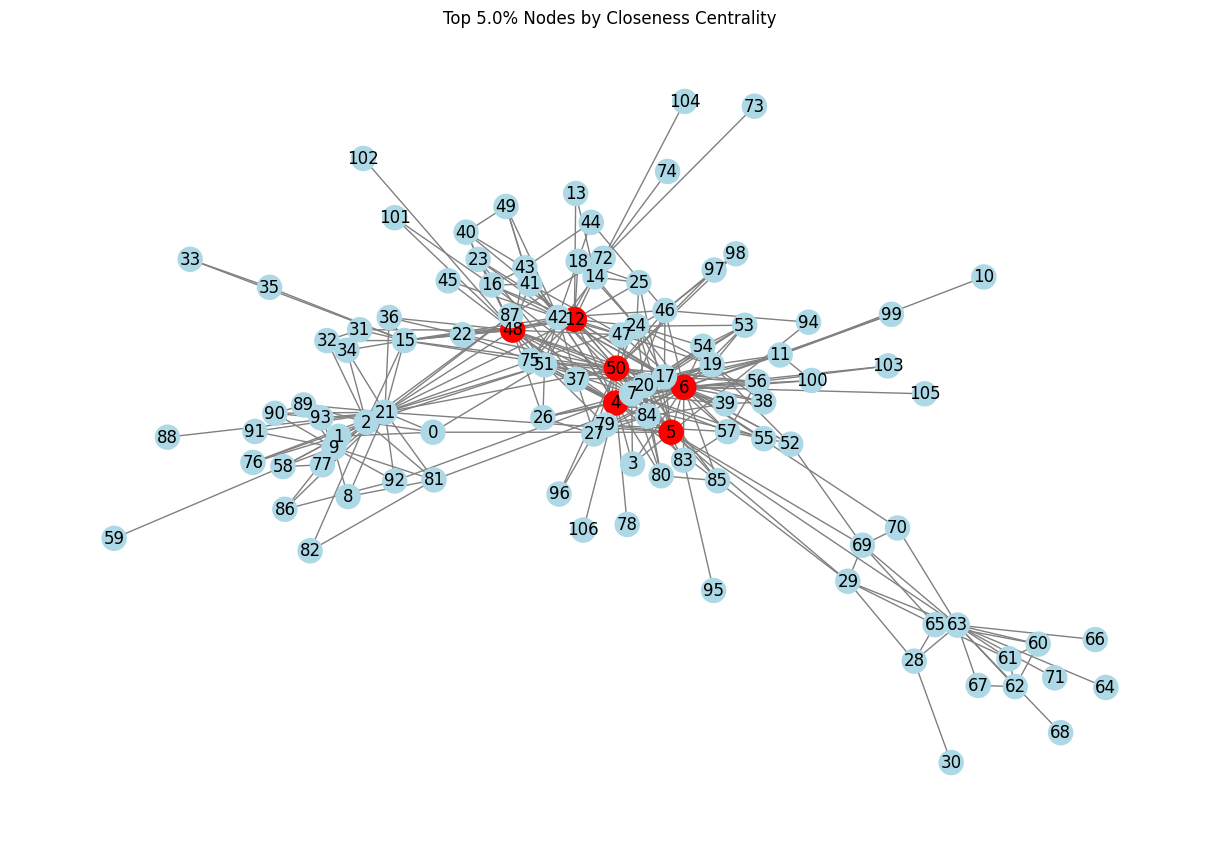

Top 5% nodes by closeness centrality:
Node: Tyrion, Number: 6, Closeness Centrality: 0.512077
Node: Sansa, Number: 50, Closeness Centrality: 0.509615
Node: Robert, Number: 5, Closeness Centrality: 0.500000
Node: Robb, Number: 48, Closeness Centrality: 0.488479
Node: Arya, Number: 12, Closeness Centrality: 0.486239
Node: Jaime, Number: 4, Closeness Centrality: 0.479638


In [65]:
def detect_closeness_centrality(graph, top_percent=5.0):
    G = graph
    N = G.number_of_nodes()

    closeness = {}

    for n in G.nodes():
        dist = nx.single_source_shortest_path_length(G, n)  # dict: node -> distance
        reachable = len(dist)

        if reachable <= 1:
            closeness[n] = 0.0
            continue

        total_dist = sum(dist.values())

        # closeness calculation
        c = (reachable - 1) / total_dist

        closeness[n] = c

    items = sorted(closeness.items(), key=lambda x: x[1], reverse=True)
    k = max(1, math.ceil(len(items) * (top_percent / 100.0)))
    top_nodes = dict(items[:k])
    return top_nodes

def plot_top_closeness(graph, top_percent=5.0):
    top_nodes = detect_closeness_centrality(graph, top_percent)
    G = graph.copy()

    node_colors = ["red" if node in top_nodes else "lightblue" for node in G.nodes()]
    pos = nx.spring_layout(G, seed=67)
    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=300, edge_color='gray')
    plt.title(f"Top {top_percent}% Nodes by Closeness Centrality")
    plt.show()


plot_top_closeness(G, top_percent=5.0)
# Map node id -> character name
id_to_name = nodes.set_index(nodes["index"].astype(int))["name"].to_dict()

# Print top 5%
top_closeness = detect_closeness_centrality(G, top_percent=5.0)

print("Top 5% nodes by closeness centrality:")
for node_id, score in top_closeness.items():
    name = id_to_name.get(int(node_id), "Unknown")
    print(f"Node: {name}, Number: {node_id}, Closeness Centrality: {score:.6f}")




# Week 6

For Week 6, we treated the Game of Thrones network as undirected and unweighted, and worked on the largest connected component. We applied two community-detection techniques(+ Also for fun implemented weighted modularity optimization.): modularity optimization (Newman greedy) and label propagation. Newman greedy starts with each node as its own community and iteratively merges the pair that gives the largest positive modularity gain, keeping the partition with the best Q. Label propagation initializes labels and repeatedly updates each node to the most frequent neighbor label until convergence. We ran it multiple times and kept the best modularity result. In our outputs, label propagation achieved Q=0.462745 with 6 communities, while unweighted Newman gave Q=0.458432 with 5 communities. Since modularity is the objective for partition quality, label propagation is slightly better here, although both methods produced very close results.

In [ ]:
# Modularity Optimization - Newman Greedy

def find_communities(graph, algorith_type: Literal["Newman"] = "Newman", weighted = False):
    if algorith_type == "Newman":
        return newman_greedy(graph, weighted=weighted)

def newman_greedy(graph: nx.Graph, weighted = False):
    edges_list = list(graph.edges(data=True)) # [('A', 'B', {'weight': 5}), ('A', 'C', {'weight': 2})]
    edges_lookup_dict = {}

    for edge in edges_list: # creating a fast lookup of edges
        u = edge[0]
        v = edge[1]
        if weighted == True:
            w = edge[2]["weight"]
        else:
            w = 1.0

        if u not in edges_lookup_dict:
            edges_lookup_dict[u] = {}
        if v not in edges_lookup_dict:
            edges_lookup_dict[v] = {}

        edges_lookup_dict[u][v] = float(w) # {A: {B: 5, C:4}}
        edges_lookup_dict[v][u] = float(w) # {B: {A:5, D:2}}

    nodes_set = set(graph.nodes()) # set of nodes with no duplicates

    for node in nodes_set:
        if node not in edges_lookup_dict:
            edges_lookup_dict[node] = {}

    nodes_degree_dict = {}
    for node in nodes_set:
        weight_sum = sum(edges_lookup_dict[node].values())
        nodes_degree_dict[node] = weight_sum

    L = sum(nodes_degree_dict[node] for node in nodes_set) / 2 # divide by 2 because each undirected edge is counted twice

    communities_dict = {}

    # initialize each node is its own community
    for node in nodes_set:
        community_id = node  # simplest id strategy for now

        communities_dict[community_id] = {
            "nodes": {node},  # set[node]
            "k_c": nodes_degree_dict[node],  # community strength
            "L_c": 0.0,  # internal weight
        }

    # We compute Q once for the initial partition.
    # Later we update it by modularity gain (delta Q)
    current_Q = calculate_community_modularity(L, communities_dict)
    best_Q = current_Q
    best_partition = clone_partition(communities_dict)
    merge_counter = 0

    # Cache of inter-community weights e_xy.
    # At the start, every community is just one node, so this is simply edge weights.
    e_cache = build_intercommunity_cache(edges_list, weighted=weighted)

    while True:
        community_ids = list(communities_dict.keys())
        if len(community_ids) <= 1:
            break

        iteration_best_delta_q = 0.0
        best_pair = None
        best_pair_e_xy = 0.0

        for i in range(len(community_ids)):
            for j in range(i + 1, len(community_ids)):
                cid_x = community_ids[i]
                cid_y = community_ids[j]

                community_x = communities_dict[cid_x]
                community_y = communities_dict[cid_y]

                e_xy = e_cache.get(cid_x, {}).get(cid_y, 0.0)
                delta_q = compute_modularity_gain(
                    L,
                    community_x["k_c"],
                    community_y["k_c"],
                    e_xy,
                )

                if delta_q > iteration_best_delta_q:
                    iteration_best_delta_q = delta_q
                    best_pair = (cid_x, cid_y)
                    best_pair_e_xy = e_xy

        # no improving merge -> stop
        if best_pair is None:
            break

        cid_x, cid_y = best_pair
        community_x = communities_dict[cid_x]
        community_y = communities_dict[cid_y]

        merged_id = f"merge_{merge_counter}_{cid_x}_{cid_y}"
        merged_community = merge_communities(community_x, community_y, best_pair_e_xy)

        del communities_dict[cid_x]
        del communities_dict[cid_y]
        communities_dict[merged_id] = merged_community

        update_intercommunity_cache(e_cache, cid_x, cid_y, merged_id, communities_dict)

        current_Q = current_Q + iteration_best_delta_q
        merge_counter += 1

        if current_Q > best_Q:
            best_Q = current_Q
            best_partition = clone_partition(communities_dict)


    return best_Q, len(best_partition), best_partition

def calculate_community_modularity(L: int, c):
    if L <= 0:
        raise ValueError("L = 0 (or less), division by zero is not allowed.")

    c_sum = 0

    for community in c.values():
        L_c = community["L_c"]
        k_c = community["k_c"]
        c_sum += L_c - (k_c**2) / (4 * L)

    return (1/L) * c_sum

def clone_partition(partition: dict):
    return {
        cid: {
            "nodes": set(data["nodes"]),
            "k_c": float(data["k_c"]),
            "L_c": float(data["L_c"]),
        }
        for cid, data in partition.items()
    }

def build_intercommunity_cache(edges_list: list, weighted = False):
    cache = {}

    for edge in edges_list:
        u = edge[0]
        v = edge[1]
        w = float(edge[2]["weight"]) if weighted else 1.0

        if u not in cache:
            cache[u] = {}
        if v not in cache:
            cache[v] = {}

        cache[u][v] = cache[u].get(v, 0.0) + w
        cache[v][u] = cache[v].get(u, 0.0) + w

    return cache

def update_intercommunity_cache(e_cache: dict, cid_x, cid_y, merged_id, communities_dict: dict):
    neighbors_x = e_cache.get(cid_x, {})
    neighbors_y = e_cache.get(cid_y, {})

    e_cache[merged_id] = {}

    for cid_z in communities_dict.keys():
        if cid_z == merged_id:
            continue

        e_xz = neighbors_x.get(cid_z, 0.0)
        e_yz = neighbors_y.get(cid_z, 0.0)
        e_merged_z = e_xz + e_yz

        if e_merged_z > 0.0:
            e_cache[merged_id][cid_z] = e_merged_z

            if cid_z not in e_cache:
                e_cache[cid_z] = {}
            e_cache[cid_z][merged_id] = e_merged_z

        if cid_z in e_cache and cid_x in e_cache[cid_z]:
            del e_cache[cid_z][cid_x]
        if cid_z in e_cache and cid_y in e_cache[cid_z]:
            del e_cache[cid_z][cid_y]

    if cid_x in e_cache:
        del e_cache[cid_x]
    if cid_y in e_cache:
        del e_cache[cid_y]

def compute_modularity_gain(L: float, k_x: float, k_y: float, e_xy: float) -> float:
    # Delta Q for merging communities x and y:
    # delta = (1/L) * (e_xy - (k_x * k_y) / (2L))
    return (1.0 / L) * (e_xy - ((k_x * k_y) / (2.0 * L)))


def merge_communities(community_x, community_y, e_xy: float):
    nodes = community_x["nodes"] | community_y["nodes"]
    k_xy = community_x["k_c"] + community_y["k_c"]
    L_xy = community_x["L_c"] + community_y["L_c"] + e_xy
    return {"nodes": nodes, "k_c": k_xy, "L_c": L_xy}

print("Weighted Graph Communities...")
best_Q, num_communities, best_partition = find_communities(get_und_lcc(G), algorith_type="Newman", weighted=True)
print(f"Best Q: {best_Q:.6f}")
print(f"Number of communities: {num_communities}")

print("\nUnweighted Modularity Optimization Communities...")
best_Q, num_communities, best_partition = find_communities(get_und_lcc(G), algorith_type="Newman", weighted=False)
print(f"Best Q: {best_Q:.6f}")
print(f"Number of communities: {num_communities}")

Weighted Graph Communities...
Best Q: 0.599902
Number of communities: 7

Unweighted Modularity Optimization Communities...
Best Q: 0.458432
Number of communities: 5


In [ ]:
#Label propagation
def label_propagation_best_partition(G_lcc, n_runs=30):
    best_Q = 0.0
    best_partition = None

    for seed in range(n_runs):
        communities = list(asyn_lpa_communities(G_lcc, weight=None, seed=seed))  # unweighted
        Q = modularity(G_lcc, communities, weight=None)

        if Q > best_Q:
            best_Q = Q
            best_partition = communities

    return best_Q, best_partition

best_Q_lp, best_partition_lp = label_propagation_best_partition(get_und_lcc(G), n_runs=30)

print("Label Propagation Communities...")
print(f"Label Propagation best modularity Q: {best_Q_lp:.6f}")
print(f"Number of communities: {len(best_partition_lp)}")


Label Propagation Communities...
Label Propagation best modularity Q: 0.462745
Number of communities: 6


In [ ]:
#Gephi Graph Exporter
def partition_to_node_map(partition):
    node_to_comm = {}

    # Newman output
    if isinstance(partition, dict):
        for i, (_, data) in enumerate(partition.items()):
            for n in data["nodes"]:
                node_to_comm[n] = i

    # Label Prop output
    else:
        for i, comm in enumerate(partition):
            for n in comm:
                node_to_comm[n] = i

    return node_to_comm

def export_partition_gexf(G_lcc, partition, nodes_df=None, out_file="week6_partition.gexf"):
    H = nx.Graph()
    H.add_nodes_from(G_lcc.nodes())
    H.add_edges_from(G_lcc.edges())          
    H.remove_edges_from(nx.selfloop_edges(H))

    node_to_comm = partition_to_node_map(partition)
    nx.set_node_attributes(H, node_to_comm, "community")

    if nodes_df is not None:
        id_to_name = nodes.set_index(nodes["index"].astype(int))["name"].to_dict()
        nx.set_node_attributes(H, {n: id_to_name.get(int(n), str(n)) for n in H.nodes()}, "label")

    nx.write_gexf(H, out_file)
    print(f"Saved: {out_file}")

#Label Propagation best partition
best_Q_lp, best_partition_lp = label_propagation_best_partition(get_und_lcc(G), n_runs=30)
export_partition_gexf(get_und_lcc(G), best_partition_lp, nodes_df=nodes, out_file="week_6_best_partition.gexf")

Saved: week_6_best_partition.gexf


# Week 7


explanation

In [ ]:
# week 7

# Week 9

explanation

In [ ]:
# week 9

# Week 10

explanation

In [ ]:
# week 10

# misc

In [114]:
def map_data():
    g = Network(height="15000px", width="100%",
                bgcolor="#222222", font_color="white")


# Introduction

intro

# Conclusion

conclusion